<a href="https://colab.research.google.com/github/0xawasthi/ML-learning/blob/main/regression_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intro to Machine Learning
**Machine Learning has two categories:**

- **Classification:** Its simply categorizing an unknown variable to a known state. That means, we will have a dataset along with categories as a training examples. Now our task would be, to classify any variable to one of the predefined categories, then we call it as a classification problem. Eg- cat vs dog classification, disease classification problem, face recognition system, vehicle number plate detection and classifier, etc..

- **Regression:** Its simply a prediction. When we have a numbers of data in a columns or strucutured data, and we need to predict based upon hisotorical dataset, then we call it as regression problem. E.g house prices prediction, stock marget prediction. That means anything related with prediction, we call it as regression problem

**Our task:**

A user wants to sell a car on an online classified website, and the site asks them to enter a price. If they dont know much the car is worth, they just need to guess. To those people or company, we want to help: How? the user describes the car, and our Machine learning model suggest the best prices.

**Question:** Which type of problem is this? Regression or Classification?

-> Regression

car:
- model
- km running
- condition
- numbers of hands
- resale
- parts avaialbity

To start any machine learning Model, here are the checklist:
-  dataset (https://www.kaggle.com/datasets/CooperUnion/cardataset)

for this project, lets collect the data from kaggle

## Implementation Guidelines:
**Our plan:**
To start this project, we will follow several steps:
- Get the data and do exploratory data analysis: Just look at the data and try learn more about data

- Prepare the dataset into train for linear regression model to predict price of the car

- Go into the details of how linear regression is implemented,

- Once you build the model, you need to evaluate the quality of your model with LR: RMSE. RMSE stands for root mean square error, a metric for evaluating quality of model prediction

- Do some feature engineering: The process of creating a new features, new characterisitcs that we can use for our model

- Deal with numerical stability problems and see how to solve them with regularization

- Finally, use that model

## Data Preparation

You need to work with data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url = '/content/drive/MyDrive/ML_datasets/car features data.csv'
df = pd.read_csv(url)

In [ ]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

Problems identified
- looking at columns, there is some inconsistency, i.e sometime there are uppercase letter (Make, Model), sometimes,,there are spaces (Engine Fuel Type), sometime underscore (_)

Our tasks:

1.
- lets make it uniform converting all columns header into lowercase,
e.g Model -> model
- also replace space with _  i.e Driven_Wheels -> driven_wheels , Engine HP -> engine_hp

In [ ]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

2. Finding out string columns
- we need to find out which columns are string, we cannot apply string method to numbers. For that we use dtypes attributes. It tells us, for every column, what type of data it is

In [ ]:
df.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


3. Normalize the data as well, means lowercase the values and replace spaces with underscore

In [ ]:
# Select columns that contains text/string
text_cols = df.select_dtypes(include=['object']).columns

# Normalize those specific columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower().str.replace(' ', '_')

In [ ]:
df.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


## Exploratory Data Analysis

we look for every column, see what kind of values are there, and try to get a feeling for the data and the problem before we create a model

- In this steps, your main agenda should be to learn more and more about data
- we already know, some columns are strings and some are numbers, To see what is inside each of them, we iterete over all the columns,and print some stat for every one, the column name, a few values, and the numbers of unique values.
- Distribution of prices: we need to figure out the distribution of prices,.

for visualizing we need to implement matplotlib.
- for this, we can visualize, the price against

- Also check for null counts, if any for all the columns

In [ ]:
df.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  object 
 1   model              11914 non-null  object 
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11914 non-null  object 
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  object 
 7   driven_wheels      11914 non-null  object 
 8   number_of_doors    11908 non-null  float64
 9   market_category    11914 non-null  object 
 10  vehicle_size       11914 non-null  object 
 11  vehicle_style      11914 non-null  object 
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.duplicated().sum()

np.int64(715)


--- Column-wise Statistics ---

Column: make
Number of unique values: 48
Sample values: ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

Column: model
Number of unique values: 914
Sample values: ['silverado_1500', 'tundra', 'f-150', 'sierra_1500', 'beetle_convertible']

Column: year
Number of unique values: 28
Min: 1990, Max: 2017, Mean: 2010.38

Column: engine_fuel_type
Number of unique values: 11
Sample values: ['regular_unleaded', 'premium_unleaded_(required)', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']

Column: engine_hp
Number of unique values: 356
Min: 55.0, Max: 1001.0, Mean: 249.39

Column: engine_cylinders
Number of unique values: 9
Min: 0.0, Max: 16.0, Mean: 5.63

Column: transmission_type
Number of unique values: 5
Sample values: ['automatic', 'manual', 'automated_manual', 'direct_drive', 'unknown']

Column: driven_wheels
Number of unique values: 4
Sample values: ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_dri

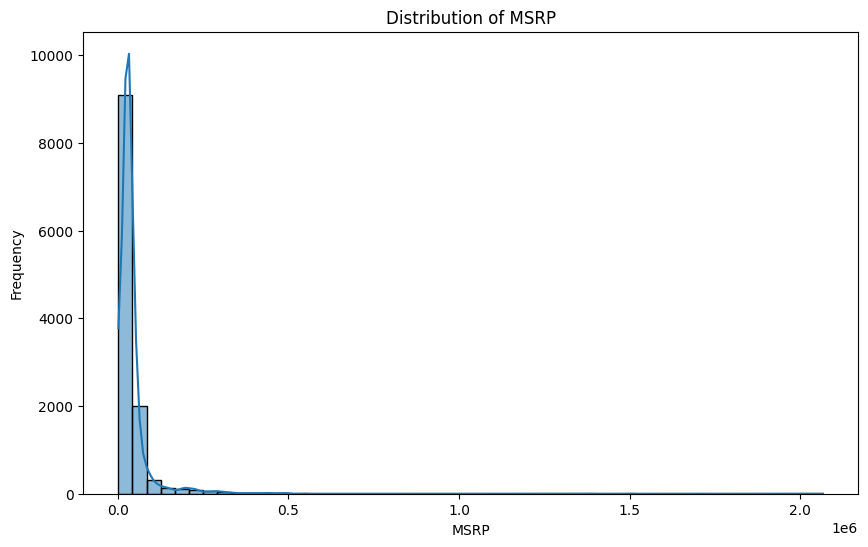


MSRP statistics:
count    1.191400e+04
mean     4.059474e+04
std      6.010910e+04
min      2.000000e+03
25%      2.100000e+04
50%      2.999500e+04
75%      4.223125e+04
max      2.065902e+06
Name: msrp, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Column-wise Statistics ---")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    if df[col].dtype == 'object':
        print(f"Sample values: {df[col].value_counts().head(5).index.tolist()}")
    else:
        print(f"Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")

print("\n--- Price Distribution (MSRP) ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['msrp'], bins=50, kde=True)
plt.title('Distribution of MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

print("\nMSRP statistics:")
print(df['msrp'].describe())

In [ ]:
df.isnull().sum()

,0
make,0
model,0
year,0
engine_fuel_type,0
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,0


## Validation Framework

Dataset is cleaned, explored. Now, we need to split the dataset into train, validation and testing parts. We need to prepare the target variable for each part. We do it manually using pandas and numpy for now.

Calculating the size of the parts:
- We will do 60/20/20. So we first need to calculate how many records 20% actually is. Our dataframe has almost 12k records, so 20% of that would be approx 2400. We want a whole number of records, not a friction like 2382.56. Thus, we will cut the fraction off with int().

In [ ]:
n = len(df)
n

11914

In [ ]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
# n_train = int(n * 0.6) This causes difference due to rounding off
n_train = n - (n_val + n_test)

In [ ]:
n, n_train, n_test, n_val

(11914, 7150, 2382, 2382)

**Taking a part of the dtaframe with iloc**

Now, we know the sizes, and we need to take a part of the dataframe of that size.  For that we use ```iloc```, which we have already studied.
we usually give it a list of indices, but it also accespts range.
eg to get first 10 records

In [ ]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


Take away: i used range, it gives 10 records, inclusive of record 0 but exclusive of record 10.

So the simplest thing we can do is cut the dataframe sequentially

In [ ]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [ ]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val + n_test]
df_train = df.iloc[n_val + n_test:]

we noticed here, while splitting sequentially, the dataset is being filtered by the column name, make. So, we validation contains only bmw, training contains only one specific car, and same for testing. which is a red flag.

Thats the reason, ALWAYS, SHUFFLE THE DATASET BEFORE YOU PASS IT FOR MODEL TRAINING

We need to shuffle the dataset,  we can use np.random.shuffle

In [ ]:
n, n_train, n_test, n_val

(11914, 7150, 2382, 2382)

In [ ]:
idx = np.arange(n)
np.random.shuffle(idx)

In [ ]:
#@ Now, we index the dataframe with the shuffled numbers instead of sequential ranges

In [ ]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

Still theres a problem??????

The problem is, everytime, you run this code, you will get a new random data for each df_train,test, val.

 you will end of developing a model under this condition, when the model accuracy is not satified, you need to retrain the model with tweaked parameter. But this time, when you split, again the data is shuffled, that means, you wont be able to get the same data that have been used previously

In [ ]:
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [ ]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [ ]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [ ]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,nan,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,nan,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


looking at the dataset, we encountered that, the index of the dataframe is also shuffled, we can reset the index for this scenario

In [ ]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [ ]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,nan,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,nan,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


So far, we have completed data cleaning and made it ready for model training

- our task was to predict the price of a car

We will start with very basic model, call it as linear regression model.

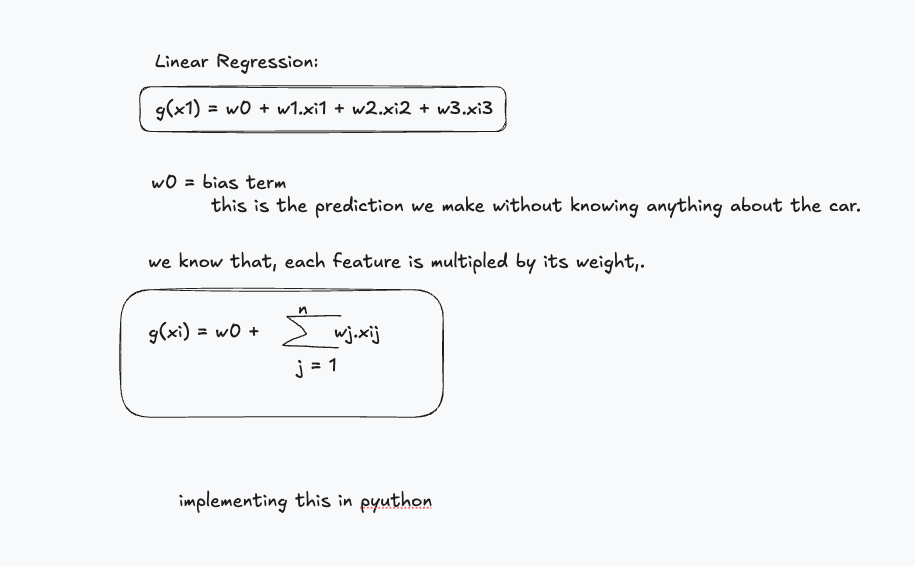

In [ ]:
#@ We have feature vector xi, the bias term, w0 and a vector w with a weight for each feature

xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [ ]:
#@ Lets create a function to implement the above output function
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j] # pred = w0 + 0.01 * 453

    return pred

In [ ]:
#@ Lets apply this mathematics to our car

linear_regression(xi)

12.312

In [ ]:
7.17 + 453*0.01 + 11*0.04 + 86*0.002

12.312

Lets implement linear regression in our system

In [ ]:
df_train.head(15)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,nan,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,nan,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
5,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,17575
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,191400
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,76100
8,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,379050
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,nan,large,regular_cab_pickup,18,13,5657,26030


In [ ]:
# linear regression, multiple linear regression, left tailed, right tailed, long tailed, log transformation
# how linear regression works

Preparing y and removing msrp:

the df will be used to make the feature matrix X, The target y comes from the msrp column and we already know that we need to apply some mathematical function, to handle its distribution.

Lets apply log function to msrp column

In [ ]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,nan,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,nan,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [ ]:
y_train = np.log1p(df_train.msrp.values)
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978])

In [ ]:
np.expm1(9.57574708)

np.float64(14409.999959096362)

In [ ]:
np.expm1(9.887663)

np.float64(19684.99995690426)

In [ ]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [ ]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [ ]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,nan,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,nan,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


## Linear Regression

Linear Regression in the form of Vector:

Just now, we observed the prediction of a single car. What do we need to do to predict the price of

In [ ]:
#@ If we apply this compact notation in our system

def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [ ]:
#@ Now implementing linear regresison function

def linear_regression(xi):
    return w0 + dot(xi, w)

In [ ]:
# Xi = Xi0 + Xi
# Xi0 = 1

# Xi = [1] + Xi

In [ ]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

In [ ]:
X = [x1, x2, x10]
X = np.array(X)

In [ ]:
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [ ]:
#@ Now I need vector weights

w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [ ]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [ ]:
#@ We need to is multiply this matrix with vector

In [ ]:
def linear_regression(X):
    return X.dot(w_new)

In [ ]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [ ]:
#@ Lets implement above login into a function
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

Lets move onto our core dataset, car price data to build our first model.

- It is the simple varsion as we will only be dealling with numerical features. So its quality is the reference point we will try to improve.

Selecting the base features

In [ ]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,nan,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,nan,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


In [ ]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

Lets consider only numbers
- engine_hp
- engine_cylinders
- highway_mpg
- city_mpg
- popularity

In [ ]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [ ]:
X_train = df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [ ]:
#@ Lets try to train the model right away

w0, w = train_linear_regression(X_train, y_train)

In [ ]:
w0, w

(np.float64(nan), array([nan, nan, nan, nan, nan]))

We observed that both the bias and the weights are nan, i.e, not a number

In [ ]:
df_train[base].isnull().sum()

,0
engine_hp,40
engine_cylinders,14
highway_mpg,0
city_mpg,0
popularity,0


We observed that, engine hp and engine cylinders have null values. The easiest way to deal the null values is replacing with zeros.

In [ ]:
X_train = df_train[base].fillna(0).values

A car with 0 hp doesn't exist, no engine has 0 cylinder, but still it works. For that, we need to look into linear regression formula.

Suppose, we have two features, and the first feature is missing

g(xi) = w0 + xi1.w1 + xi2.w2 (xi1 is missing)

= w0 + 0.w1 + xi2.w2

= w0 + xi2.w2

when xi1 is 0, then the term xi1.w1 disapperas, the model successfully ignores the features.

In [ ]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)

In [ ]:
w0, w

(np.float64(7.927257388069986),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [ ]:
y_pred = w0 + X_train.dot(w)

In [ ]:
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111])

To see how our model worked, we need to plot them as a historgram and compare with the histrogram of the actual traget values. for this, we use the same function we used during eda

<Axes: ylabel='Count'>

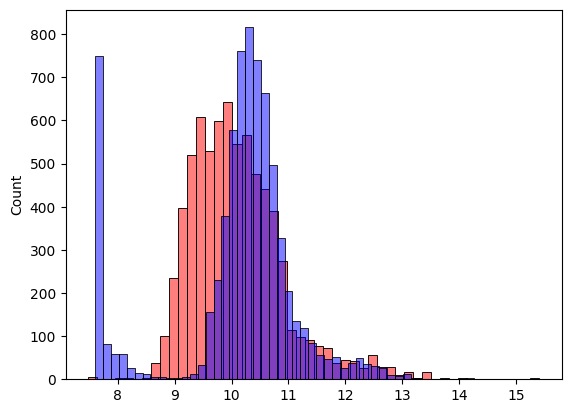

In [ ]:
sns.histplot(y_pred, color = 'red', alpha=0.5, bins=50, label='predicted values')
sns.histplot(y_train, color = 'blue', alpha=0.5, bins=50, label='actual values')

Just looking at the diagram, it is difficult to interpret the model accuracy. Thus we need to have a parameter, that can give us evaluation comparision

For the case of prediction Model, we have one popular matrix, which is

RMSE. Root Mean Square Error
- It gives the difference between prediction and actual values.
- For each observation i, g(xi) is the prediction we make and yi is the actual value.
- thus we take the difference, square it, taking average these squared differences over all the m obbservation.  Then finally, taking square root.